In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movie_data = pd.read_csv("IMDb Movies India.csv", encoding="latin1")
movie_data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
movie_data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [5]:
movie_data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [7]:
for col in movie_data.columns:
    if movie_data[col].dtype == 'object':
        movie_data[col] = movie_data[col].astype(str).str.strip()

In [8]:
if 'Name' in movie_data.columns:
    movie_data.drop('Name', axis=1, inplace=True)

In [9]:
movie_data.dropna(inplace=True)

In [10]:
if 'Duration' in movie_data.columns:
    movie_data['Duration'] = movie_data['Duration'].str.replace('min', '', regex=False)
    
    movie_data['Duration'] = pd.to_numeric(movie_data['Duration'], errors='coerce')
    
    movie_data['Duration'] = movie_data['Duration'].fillna(movie_data['Duration'].mean())
    
    movie_data['Duration'] = movie_data['Duration'].astype(int)

In [11]:
if 'Votes' in movie_data.columns:
    movie_data['Votes'] = movie_data['Votes'].astype(str)
    movie_data['Votes'] = movie_data['Votes'].str.replace(',', '', regex=False) # Regex is used to find text based on patterns
    movie_data['Votes'] = movie_data['Votes'].astype(int)

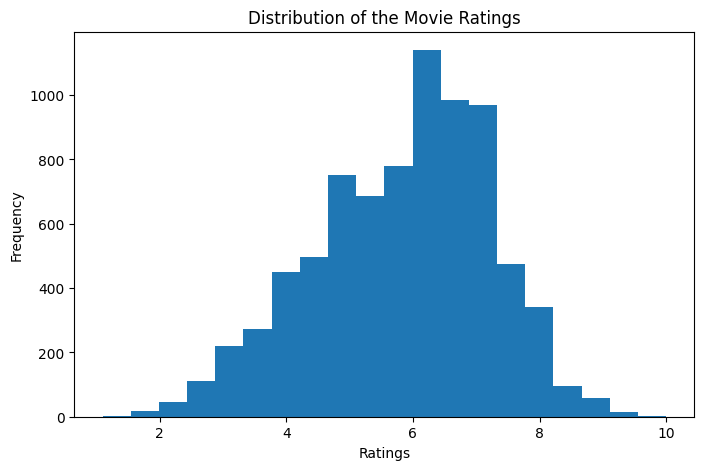

In [12]:
plt.figure(figsize=(8,5))
plt.hist(movie_data['Rating'], bins=20)
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of the Movie Ratings')
plt.show()

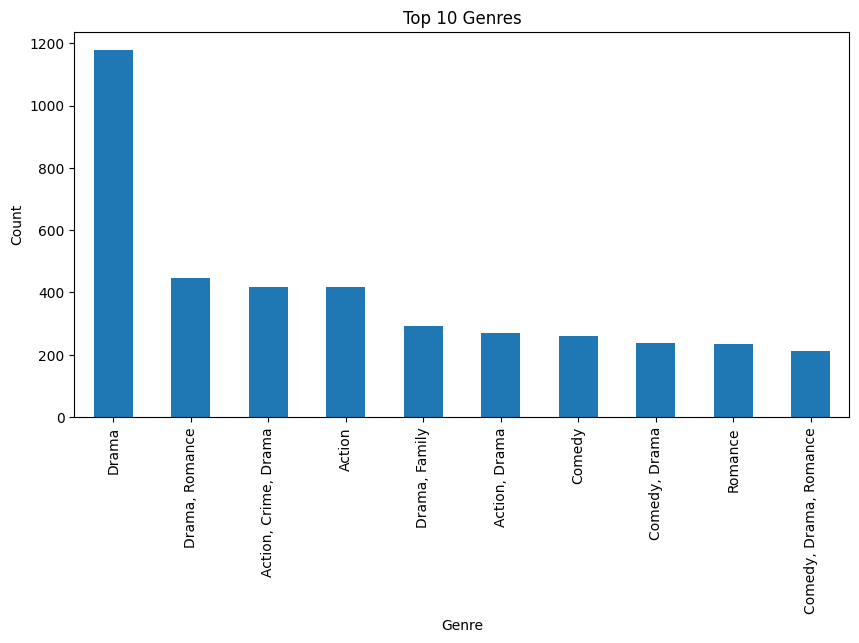

In [13]:
plt.figure(figsize=(10,5))

movie_data['Genre'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

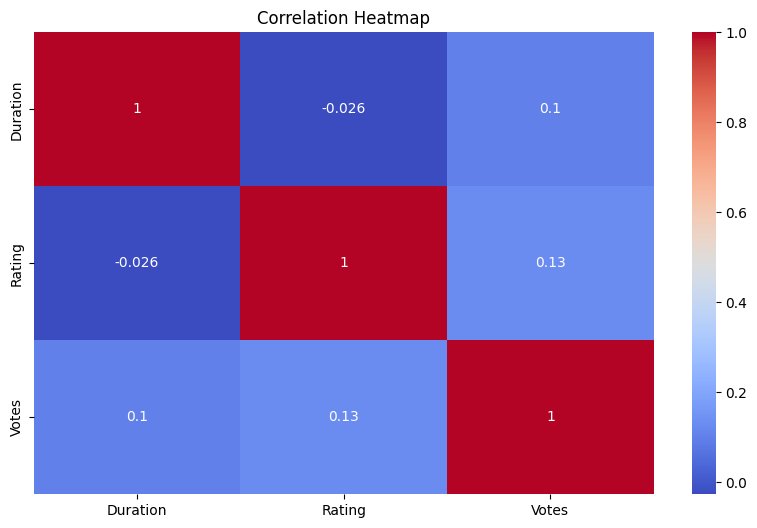

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(movie_data.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in movie_data.columns:
    if movie_data[col].dtype == 'object':
        movie_data[col] = le.fit_transform(movie_data[col])

In [16]:
X = movie_data.drop('Rating', axis=1)

y = movie_data['Rating']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred = lr.predict(X_test)

In [20]:
print('Linear Regression Results')
print('MAE :', mean_absolute_error(y_test, y_pred))
print('MSE :', mean_squared_error(y_test, y_pred))
print('R2 Score :', r2_score(y_test, y_pred))

Linear Regression Results
MAE : 1.0316768139438168
MSE : 1.6724031124749665
R2 Score : 0.10044510462643608


In [21]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
rf_pred = rf.predict(X_test)

In [23]:
print('Random Forest Results')
print('MAE :', mean_absolute_error(y_test, rf_pred))
print('MSE :', mean_squared_error(y_test, rf_pred))
print('R2 Score :', r2_score(y_test, rf_pred))

Random Forest Results
MAE : 0.8266376262626262
MSE : 1.1990849595959598
R2 Score : 0.35503423945612667


In [24]:
comparison = pd.DataFrame({'Actual Rating': y_test,'Predicted Rating': rf_pred})
print(comparison.head(10))

       Actual Rating  Predicted Rating
9456             3.3             4.296
14816            5.3             5.172
3213             5.7             5.244
3778             7.2             5.347
5775             3.5             5.273
12203            7.2             6.015
12305            3.8             5.531
4650             6.9             6.980
8701             5.2             5.585
4707             7.4             5.925


In [25]:
importance = rf.feature_importances_
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names,'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

    Feature  Importance
3     Votes    0.215423
0      Year    0.197748
2     Genre    0.121765
7   Actor 3    0.097720
5   Actor 1    0.095745
6   Actor 2    0.095098
1  Duration    0.091102
4  Director    0.085400


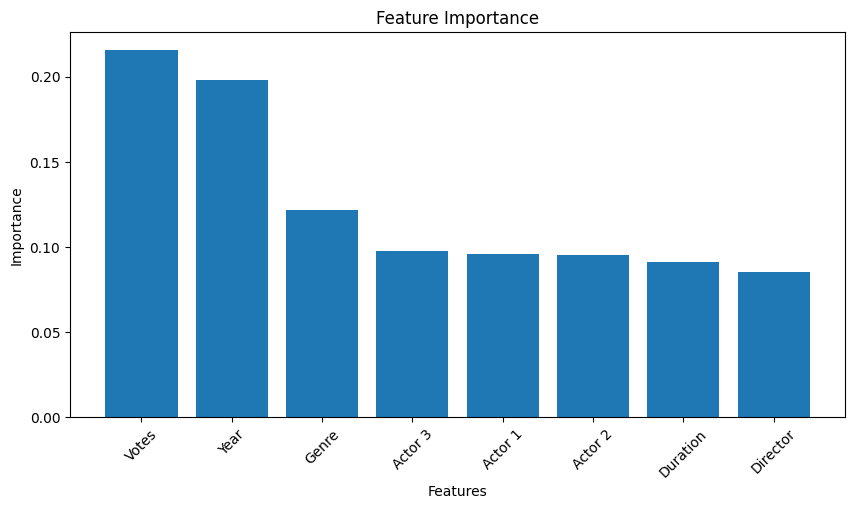

In [26]:
plt.figure(figsize=(10,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [27]:
print('Movie Rating Prediction Task Completed Successfully')

Movie Rating Prediction Task Completed Successfully
